## **Classification and Captioning Aircraft Damage Using Pretrained Models**


**Introduction**

I am building an AI system to classify aircraft damage using VGG16 and generate captions using a Transformer model.

**Project Overview**

Aircraft damage detection plays a critical role in ensuring aviation safety and operational efficiency. Traditional inspection methods are often time-consuming, costly, and susceptible to human error.

In this project, I focus on automating the detection and classification of aircraft damage into two categories: "dent" and "crack". I leverage the power of transfer learning by using a pre-trained VGG16 model for feature extraction and image classification.

**Aim of the Project**

The primary goal is to build an accurate model for automated aircraft damage classification.

Develop a VGG16-based deep learning model for image classification
Use feature extraction to enhance performance
Integrate a Transformer model for caption generation
Design a system applicable to real-world aviation inspection

**Final Output**

- A trained model capable of classifying aircraft images into "dent" and "crack" categories, enabling automated aircraft damage detection.
- A Transformer-based model that generates captions and summaries of images


 **Table of Contents**
 
1 Dataset Preparation

2 Data Preprocessing

3 Model Definition

4 Model Training

5 Visualizing Training Results

6 Model Evaluation

7 Visualizing Predictions
        



**1. Dataset-Preparation**


In [1]:
import warnings
warnings.filterwarnings('ignore') #suppress the warning messages

In [3]:
!pip install pandas==2.2.3
!pip install tensorflow_cpu==2.17.1
!pip install pillow==11.1.0
!pip install matplotlib==3.9.2
!pip install transformers==4.38.2
!pip install torch==2.2.0 torchvision==0.17.0 torchaudio==2.2.0 --index-url https://download.pytorch.org/whl/cpu


[notice] A new release of pip available: 22.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Looking in indexes: https://download.pytorch.org/whl/cpu
     -------------------------------------- 200.8/200.8 MB 2.4 MB/s eta 0:00:00
     ---------------------------------------- 1.2/1.2 MB 2.6 MB/s eta 0:00:00
     ---------------------------------------- 2.4/2.4 MB 2.5 MB/s eta 0:00:00
  Using cached networkx-3.4.2-py3-none-any.whl (1.7 MB)
  Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
  Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)



[notice] A new release of pip available: 22.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [5]:
import zipfile
import keras
from keras.models import Sequential, Model
from keras.layers import Dense, Dropout, Flatten
from keras.applications import VGG16
from keras.optimizers import Adam
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
from keras.preprocessing import image
import random

In [6]:
# Set seed for reproducibility
seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

**Pretrained Model**
* Use ResNet/VGG for image classification to extract meaningful visual features
* Use BLIP for generating captions and summaries from images

In [7]:
#Set the batch size,epochs
batch_size = 32
n_epochs = 5
img_rows, img_cols = 224, 224
input_shape = (img_rows, img_cols, 3)

In [8]:
import os

# Path to your dataset folder (change this to your actual path)
dataset_path = "aircraft_damage_dataset_v1"

# Example: dataset structure check
if os.path.exists(dataset_path):
    print(f"Dataset found at: {dataset_path}")
    
    # List main folders (e.g., train, test, valid)
    for folder in os.listdir(dataset_path):
        folder_path = os.path.join(dataset_path, folder)
        
        if os.path.isdir(folder_path):
            print(f"\n📁 {folder} contains:")
            
            # List classes inside each folder
            for class_name in os.listdir(folder_path):
                class_path = os.path.join(folder_path, class_name)
                
                if os.path.isdir(class_path):
                    num_images = len(os.listdir(class_path))
                    print(f"  - {class_name}: {num_images} images")
else:
    print("Dataset path does not exist. Please check the path.")

Dataset found at: aircraft_damage_dataset_v1

📁 test contains:
  - crack: 26 images
  - dent: 25 images

📁 train contains:
  - crack: 150 images
  - dent: 150 images

📁 valid contains:
  - crack: 48 images
  - dent: 48 images


The folder structure looks as follows:

```python
aircraft_damage_dataset_v1/
├── train/
│   ├── dent/
│   └── crack/
├── valid/
│   ├── dent/
│   └── crack/
└── test/
    ├── dent/
    └── crack/

```



In [11]:
# Define directories for train, test, and validation splits
extract_path = "aircraft_damage_dataset_v1"
train_dir = os.path.join(extract_path, 'train')
test_dir = os.path.join(extract_path, 'test')
valid_dir = os.path.join(extract_path, 'valid')

**Data Preprocessing**

In [12]:
# Create ImageDataGenerators to preprocess the data
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

Use flow_from_directory() method to load the images from directory and generate the training validating and testing dataset


In [13]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_rows, img_cols),   # Resize images to the size VGG16 expects
    batch_size=batch_size,
    seed = seed_value,
    class_mode='binary',
    shuffle=True # Binary classification: dent vs crack
)

Found 300 images belonging to 2 classes.


In [14]:
valid_generator =  valid_datagen.flow_from_directory(
    directory= valid_dir,
    class_mode= 'binary',
    seed= seed_value,
    batch_size= batch_size,
    shuffle= False,
    target_size= (img_rows, img_cols)
)


Found 96 images belonging to 2 classes.


In [15]:
test_generator =  test_datagen.flow_from_directory(
    directory= valid_dir,
    class_mode= 'binary',
    seed= seed_value,
    batch_size= batch_size,
    shuffle= False,
    target_size= (img_rows, img_cols)
)



Found 96 images belonging to 2 classes.


 Load the pre-trained model VGG16

In [17]:
base_model = VGG16(weights='imagenet' , include_top=False  , input_shape=(img_rows, img_cols, 3))


In [18]:
# Modify the VGG16 model for our classification task
output = base_model.layers[-1].output
output = keras.layers.Flatten()(output)
base_model = Model(base_model.input, output)

# Freeze the base VGG16 model layers
for layer in base_model.layers:
    layer.trainable = False

In [19]:
# Build the custom model
model = Sequential()
model.add(base_model)
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

In [20]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Model Training

In [21]:
#Enter your code here
# Write your code here
history = model.fit(
    train_generator,
    epochs=n_epochs,
    validation_data=valid_generator
)

Epoch 1/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 104s 11s/step - accuracy: 0.5233 - loss: 0.8047 - val_accuracy: 0.4896 - val_loss: 0.7889
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 100s 11s/step - accuracy: 0.6533 - loss: 0.6256 - val_accuracy: 0.6667 - val_loss: 0.6134
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 103s 11s/step - accuracy: 0.7400 - loss: 0.4939 - val_accuracy: 0.7083 - val_loss: 0.5628
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 103s 10s/step - accuracy: 0.7900 - loss: 0.4595 - val_accuracy: 0.7083 - val_loss: 0.5146
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 101s 10s/step - accuracy: 0.8633 - loss: 0.3678 - val_accuracy: 0.7292 - val_loss: 0.4911


In [22]:
# Access the training history
train_history = model.history.history  # After training

Visualizing Training Results

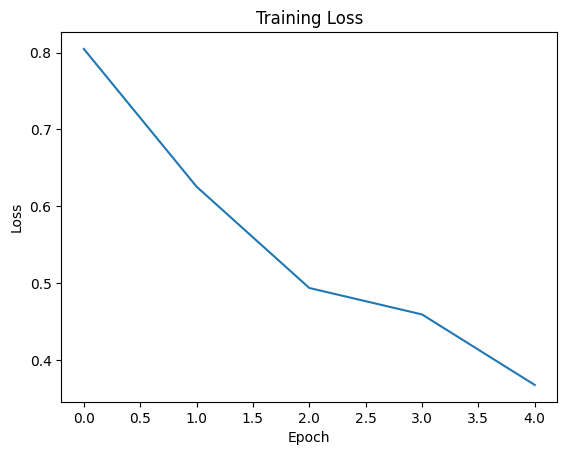

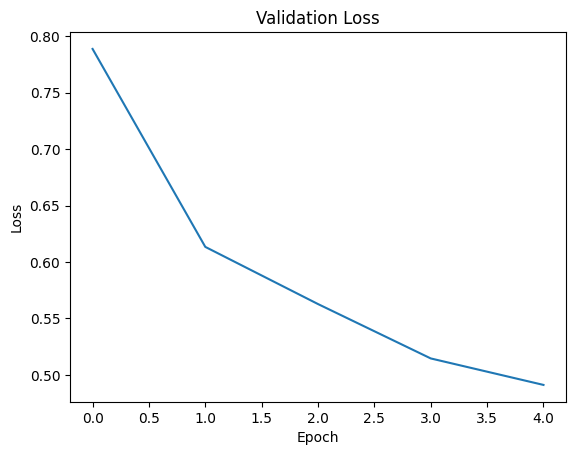

In [23]:
# Plot the loss for both training and validation
plt.title("Training Loss")
plt.ylabel("Loss")
plt.xlabel('Epoch')
plt.plot(train_history['loss'])
plt.show()

plt.title("Validation Loss")
plt.ylabel("Loss")
plt.xlabel('Epoch')
plt.plot(train_history['val_loss'])
plt.show()

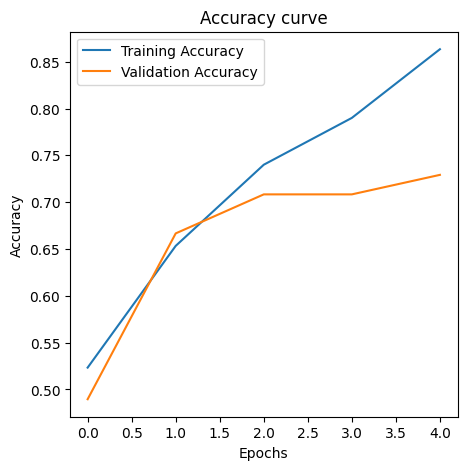

In [24]:
# Plot accuracy curves for training and validation sets
plt.figure(figsize=(5, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy curve')
plt.show()


Model Evaluation

In [25]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(test_generator, steps=test_generator.samples // test_generator.batch_size)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 24s 8s/step - accuracy: 0.7292 - loss: 0.4911
Test Loss: 0.4911
Test Accuracy: 0.7292


Visualizing Predictions

Display test images alongside their true and predicted labels.
True labels and predictions are retrieved.
Images are displayed with labels for visual inspection of model performance.


In [27]:
# Function to plot a single image and its prediction
def plot_image_with_title(image, model, true_label, predicted_label, class_names):
    plt.figure(figsize=(6, 6))
    plt.imshow(image)

    # Convert labels from one-hot to class indices if needed, but for binary labels it's just 0 or 1
    true_label_name = class_names[true_label]  # Labels are already in class indices
    pred_label_name = class_names[predicted_label]  # Predictions are 0 or 1

    plt.title(f"True: {true_label_name}\nPred: {pred_label_name}")
    plt.axis('off')
    plt.show()

# Function to test the model with images from the test set
def test_model_on_image(test_generator, model, index_to_plot=0):
    # Get a batch of images and labels from the test generator
    test_images, test_labels = next(test_generator)

    # Make predictions on the batch
    predictions = model.predict(test_images)

    # In binary classification, predictions are probabilities (float). Convert to binary (0 or 1)
    predicted_classes = (predictions > 0.5).astype(int).flatten()

    # Get the class indices from the test generator and invert them to get class names
    class_indices = test_generator.class_indices
    class_names = {v: k for k, v in class_indices.items()}  # Invert the dictionary

    # Specify the image to display based on the index
    image_to_plot = test_images[index_to_plot]
    true_label = test_labels[index_to_plot]
    predicted_label = predicted_classes[index_to_plot]

    # Plot the selected image with its true and predicted labels
    plot_image_with_title(image=image_to_plot, model=model, true_label=true_label, predicted_label=predicted_label, class_names=class_names)




1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


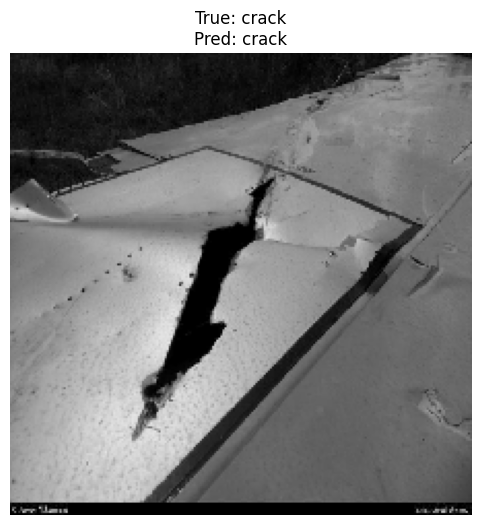

In [28]:
# Visualizing the results
test_model_on_image(test_generator, model, index_to_plot=1)


**Image Captioning and Summarization using BLIP Pretrained Model**

Use BLIP (Bootstrapping Language-Image Pretraining) to generate captions and summaries for images. It combines visual and textual understanding to produce meaningful descriptions of image content.

Integrate the BLIP model into system using a custom Keras layer, allowing input an image and choose between caption or summary generation.

Key Steps:

Load and preprocess images for model input
Generate text (caption or summary) based on the image
Implement a custom Keras layer to integrate BLIP into the workflow

In [29]:
#Load the required libraries
import torch
import tensorflow as tf
from PIL import Image
from transformers import BlipProcessor, BlipForConditionalGeneration

In [30]:
#load the pretrained BLIP processor and model:
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base") # handles the preprocessing of images and text.
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base") # responsible for generating captions or summaries based on the processed image

In [31]:
class BlipCaptionSummaryLayer(tf.keras.layers.Layer):
    def __init__(self, processor, model, **kwargs):
        """
        Initialize the custom Keras layer with the BLIP processor and model.

        Args:
            processor: The BLIP processor for preparing inputs for the model.
            model: The BLIP model for generating captions or summaries.
        """
        super().__init__(**kwargs)
        self.processor = processor
        self.model = model
    
    def call(self, image_path, task):
        result = tf.py_function(self.process_image, [image_path, task], tf.string)
        result.set_shape([])  # important
        return result
        
    def process_image(self, image_path, task):
        import torch
        from PIL import Image
    
        try:
            image_path = image_path.numpy().decode("utf-8")
            task = task.numpy().decode("utf-8")
    
            print("Processing:", image_path)
    
            image = Image.open(image_path).convert("RGB")
    
            prompt = (
                "This is a picture of"
                if task == "caption"
                else "This is a detailed photo showing"
            )
    
            inputs = self.processor(images=image, text=prompt, return_tensors="pt")
    
            device = next(self.model.parameters()).device
            inputs = {k: v.to(device) for k, v in inputs.items()}
    
            with torch.no_grad():
                output = self.model.generate(**inputs)
    
            result = self.processor.decode(output[0], skip_special_tokens=True)
    
            print("Generated:", result)
    
            return result.encode("utf-8")  # ✅ MUST be bytes
    
        except Exception as e:
            print("ERROR OCCURRED:", e)
            return b"Error processing image"  # ✅ NEVER return string        

In [32]:
# Implement a Helper Function that utilizes the custom Keras Layer to generate captions or summaries for a given image.
# The function takes an image path and a task type ("caption" or "summary"), processes the image through the BLIP layer, and returns the generated text.
def generate_text(image_path, task):
    # If tensor → convert to Python string
    if isinstance(image_path, tf.Tensor):
        image_path = image_path.numpy().decode("utf-8")

    if isinstance(task, tf.Tensor):
        task = task.numpy().decode("utf-8")

    image_path_tensor = tf.convert_to_tensor(image_path, dtype=tf.string)
    task_tensor = tf.convert_to_tensor(task, dtype=tf.string)

    result = blip_layer(image_path_tensor, task_tensor)

    return result.numpy().decode("utf-8")

In [33]:
# Path to an example image 
blip_layer = BlipCaptionSummaryLayer(processor, model)

image_path = tf.constant("aircraft_damage_dataset_v1/test/dent/144_10_JPG_jpg.rf.4d008cc33e217c1606b76585469d626b.jpg")  # sample test

# Generate a caption for the image
caption = generate_text(image_path, tf.constant("caption"))
# Decode and print the generated caption
print("Caption:", caption)

# Generate a summary for the image
summary = generate_text(image_path, tf.constant("summary"))
# Decode and print the generated summary
print("Summary:", summary)


Processing: aircraft_damage_dataset_v1/test/dent/144_10_JPG_jpg.rf.4d008cc33e217c1606b76585469d626b.jpg
Generated: this is a picture of a plane
Caption: this is a picture of a plane
Processing: aircraft_damage_dataset_v1/test/dent/144_10_JPG_jpg.rf.4d008cc33e217c1606b76585469d626b.jpg
Generated: this is a detailed photo showing the engine of a boeing 747
Summary: this is a detailed photo showing the engine of a boeing 747


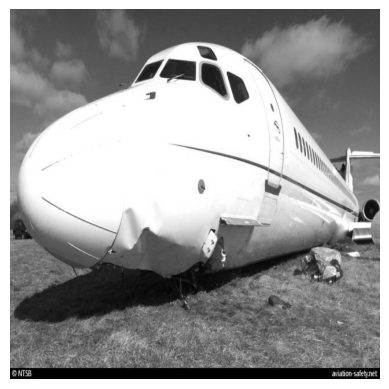

In [34]:
# Using this image to display Caption and Summary
# URL of the image
image_url = "aircraft_damage_dataset_v1/test/dent/149_22_JPG_jpg.rf.4899cbb6f4aad9588fa3811bb886c34d.jpg"
# Load and display the image
img = plt.imread(image_url)
plt.imshow(img)
plt.axis('off')  # Hide the axis
plt.show()

In [35]:
image_path = tf.constant("aircraft_damage_dataset_v1/test/dent/149_22_JPG_jpg.rf.4899cbb6f4aad9588fa3811bb886c34d.jpg")  # actual path of image

**Generate a caption for an image**

In [36]:
# Write your code here
# The given image path (already provided in the notebook)
image_path = image_path

# Convert image path and task into tensors

image_tensor = tf.constant(image_path)
task_tensor = tf.constant("caption")

# Generate caption using your helper function
caption_output = generate_text(image_tensor, task_tensor)

# Display the caption
caption_output


Processing: aircraft_damage_dataset_v1/test/dent/149_22_JPG_jpg.rf.4899cbb6f4aad9588fa3811bb886c34d.jpg
Generated: this is a picture of a plane that was sitting on the ground in a field


'this is a picture of a plane that was sitting on the ground in a field'

**Generate a summary of an image**

In [38]:
# Write your code here
image_path = image_path

image_tensor = tf.constant(image_path)
task_tensor = tf.constant("summary")

# Generate caption using your helper function
summary_output = generate_text(image_tensor, task_tensor)

# Display the caption
summary_output

Processing: aircraft_damage_dataset_v1/test/dent/149_22_JPG_jpg.rf.4899cbb6f4aad9588fa3811bb886c34d.jpg
Generated: this is a detailed photo showing the damage to the fuselage of the aircraft


'this is a detailed photo showing the damage to the fuselage of the aircraft'